# LSTM from scratch — one feature DataFrame

Loads `data/processed/feature_matrix.parquet` (the all-in-one flat feature table),
enriches it with the few raw columns it is missing, and gets you everything you need
to build your own PyTorch LSTM:

1. **Load** the flat feature matrix into one `df`
2. **Enrich** with `checkout_price`, `base_price`, `op_area` from `merged.parquet`
3. **Inspect** the long format (one row per `center_id × meal_id × week`)
4. **Scale** features (z-score, fit on train weeks only) + `log1p` target
5. **Window** the flat df into 3-D sequences `(samples, lookback, features)`
6. **Model** — a from-scratch `nn.LSTM` skeleton + training loop you own

> **Temporal integrity:** scaler statistics are fit on **train weeks (≤ 115) only**.
> The target is `log1p(num_orders)`, so a plain `MSELoss` on it already **equals RMSLE²** —
> no separate RMSLE loss is needed.

> **pyarrow note:** the project's parquet files are written by pyarrow ≥ 21, which older
> readers (e.g. Anaconda's pyarrow 19) reject with `OSError: Repetition level histogram
> size mismatch`. The `load_table()` helper below transparently falls back to `.feather`
> copies of the same data. The clean permanent fix is `pip install -U "pyarrow>=21"` in
> this kernel's environment, after which the `.feather` files are no longer needed.

## 0. Setup

In [80]:
from pathlib import Path
import numpy as np
import pandas as pd

# locate the project root no matter where the kernel starts
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / "data" / "processed" / "feature_matrix.parquet").exists():
        break
    ROOT = ROOT.parent
PROC = ROOT / "data" / "processed"
print("project root:", ROOT)

def load_table(name, columns=None):
    # Read data/processed/{name}.parquet; fall back to the .feather copy when the
    # installed pyarrow is too old to read the pipeline's parquet (pyarrow < 21 raises
    # OSError: "Repetition level histogram size mismatch"). Upgrade pyarrow
    # (pip install -U "pyarrow>=21") and you can delete the .feather files.
    try:
        return pd.read_parquet(PROC / f"{name}.parquet", columns=columns)
    except Exception as exc:
        ft = PROC / f"{name}.feather"
        if not ft.exists():
            raise
        print(f"[load_table] parquet read failed ({type(exc).__name__}); using {ft.name}")
        return pd.read_feather(ft, columns=columns)

# constants mirror src/features.py so splits line up with the rest of the project
LOOKBACK       = 26          # weeks of history fed to the LSTM
HORIZON        = 10          # weeks ahead to predict
TRAIN_MAX_WEEK = 115
SPLITS = {"train": (1, 115), "val": (116, 125), "eval": (126, 145)}
SEED = 42
np.random.seed(SEED)

project root: e:\Alireza\Article_forecast


## 0b. Make sure we run on the GPU

`torch.cuda.is_available()` is `True` only if **this kernel's torch is a CUDA build**.
A CPU-only torch (e.g. `2.10.0+cpu`, which ships in the base Anaconda env) can never see
the GPU. If the next cell raises, switch the kernel to a CUDA-enabled one — the
**"Python 3.14 (GPU, cu128)"** kernel was registered for exactly this — then re-run from the top.

In [81]:
import torch

REQUIRE_GPU = True   # set False to allow a (much slower) CPU fallback

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    p = torch.cuda.get_device_properties(0)
    print(f"GPU ready: {p.name} ({p.total_memory / 1e9:.1f} GB) | "
          f"torch {torch.__version__} (cuda {torch.version.cuda})")
else:
    DEVICE = torch.device("cpu")
    msg = (f"CUDA not available -- torch {torch.__version__} is a CPU-only build in this kernel. "
           f"Switch to the 'Python 3.14 (GPU, cu128)' kernel (or pip install a cu-build of "
           f"torch), then re-run from the top.")
    if REQUIRE_GPU:
        raise RuntimeError(msg)
    print("WARNING:", msg)

GPU ready: NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB) | torch 2.11.0+cu128 (cuda 12.8)


## 1. Load the flat feature matrix

In [82]:
df = load_table("feature_matrix")
print("feature_matrix:", df.shape)
df.head()

feature_matrix: (409950, 59)


,center_id,meal_id,week,num_orders,lag_10,lag_11,lag_12,lag_13,rolling_mean_4w,rolling_std_4w,...,meal_price_rank,meal_region_price_rank,center_week_count,center_cat_week_count,city_meal_week_count,meal_week_count,region_meal_week_count,type_meal_week_count,center_week_price_rank,meal_week_price_rank
0,10,1062,14,648,1202.0,851.0,782.0,865.0,1090.00,323.117110,...,8.0,9.0,18996,7114,3191,22265,9939,5336,5.0,20.0
1,10,1062,15,770,958.0,1202.0,851.0,782.0,941.75,290.501147,...,8.0,9.0,20521,9074,3623,24316,10707,5230,8.0,25.0
2,10,1062,16,663,1094.0,958.0,1202.0,851.0,783.75,188.177886,...,8.0,9.0,18394,8565,3774,23879,10668,5719,8.0,30.0
3,10,1062,17,1404,1513.0,1094.0,958.0,1202.0,871.25,359.296883,...,8.0,9.0,24200,9911,6727,38622,19681,8803,8.0,29.0
4,10,1062,18,757,1149.0,1513.0,1094.0,958.0,898.50,340.355207,...,8.0,9.0,24431,8966,5442,37932,16259,7573,7.0,31.0


## 2. Enrich with raw columns the matrix doesn't carry

`feature_matrix.parquet` keeps the engineered features but drops three raw ones the
LSTM can still use: `checkout_price`, `base_price`, `op_area`. Pull them from
`merged.parquet` and join on `(center_id, meal_id, week)`.

In [83]:
raw_extra = load_table(
    "merged",
    columns=["center_id", "meal_id", "week", "checkout_price", "base_price", "op_area"],
)
df = df.merge(raw_extra, on=["center_id", "meal_id", "week"], how="left")
df = df.sort_values(["center_id", "meal_id", "week"]).reset_index(drop=True)
print("enriched:", df.shape)
assert df[["checkout_price", "base_price", "op_area"]].isna().mean().max() < 0.01, "merge gap"
df.head()

enriched: (409950, 62)


,center_id,meal_id,week,num_orders,lag_10,lag_11,lag_12,lag_13,rolling_mean_4w,rolling_std_4w,...,center_cat_week_count,city_meal_week_count,meal_week_count,region_meal_week_count,type_meal_week_count,center_week_price_rank,meal_week_price_rank,checkout_price,base_price,op_area
0,10,1062,14,648,1202.0,851.0,782.0,865.0,1090.00,323.117110,...,7114,3191,22265,9939,5336,5.0,20.0,179.45,179.45,6.3
1,10,1062,15,770,958.0,1202.0,851.0,782.0,941.75,290.501147,...,9074,3623,24316,10707,5230,8.0,25.0,182.39,183.39,6.3
2,10,1062,16,663,1094.0,958.0,1202.0,851.0,783.75,188.177886,...,8565,3774,23879,10668,5719,8.0,30.0,185.33,183.33,6.3
3,10,1062,17,1404,1513.0,1094.0,958.0,1202.0,871.25,359.296883,...,9911,6727,38622,19681,8803,8.0,29.0,162.99,184.33,6.3
4,10,1062,18,757,1149.0,1513.0,1094.0,958.0,898.50,340.355207,...,8966,5442,37932,16259,7573,7.0,31.0,162.02,185.33,6.3


In [84]:
df.columns

Index(['center_id', 'meal_id', 'week', 'num_orders', 'lag_10', 'lag_11',
       'lag_12', 'lag_13', 'rolling_mean_4w', 'rolling_std_4w',
       'rolling_min_4w', 'rolling_max_4w', 'rolling_mean_8w', 'rolling_std_8w',
       'rolling_min_8w', 'rolling_max_8w', 'ewm_span10', 'ewm_span13',
       'ewm_span26', 'ewm_alpha05', 'discount_rate', 'log_checkout_price',
       'emailer_for_promotion', 'homepage_featured', 'email_x_discount',
       'homepage_x_discount', 'week_number', 'week_of_year_sin',
       'week_of_year_cos', 'center_mean_orders', 'center_std_orders',
       'meal_mean_orders', 'meal_std_orders', 'center_type_enc',
       'category_enc', 'cuisine_enc', 'base_price_max', 'base_price_mean',
       'base_price_min', 'meal_price_max', 'meal_price_mean', 'meal_price_min',
       'meal_count', 'center_cat_count', 'center_cui_count',
       'region_meal_count', 'center_price_rank', 'center_cat_price_rank',
       'meal_city_price_rank', 'meal_price_rank', 'meal_region_price_rank'

## 3. Inspect the long format

One row per `(center_id, meal_id, week)`. Each `(center_id, meal_id)` pair is one
time series that the LSTM will read week by week.

In [85]:
n_series = df.groupby(["center_id", "meal_id"]).ngroups
print(f"rows           : {len(df):,}")
print(f"time series    : {n_series:,}")
print(f"weeks          : {df['week'].min()} .. {df['week'].max()}")
print(f"target         : num_orders (raw counts) -> log1p")
print(f"feature columns: {df.shape[1] - 3}  (all but the 3 id cols; num_orders is both history-input and target)")

# one series through time
cid0, mid0 = df.loc[0, "center_id"], df.loc[0, "meal_id"]
example = df[(df.center_id == cid0) & (df.meal_id == mid0)]
example[["week", "num_orders", "checkout_price", "rolling_mean_4w"]].head()

rows           : 409,950
time series    : 3,560
weeks          : 14 .. 145
target         : num_orders (raw counts) -> log1p
feature columns: 59  (all but the 3 id cols; num_orders is both history-input and target)


,week,num_orders,checkout_price,rolling_mean_4w
0,14,648,179.45,1090.00
1,15,770,182.39,941.75
2,16,663,185.33,783.75
3,17,1404,162.99,871.25
4,18,757,162.02,898.50


## 4. Target, scaling (train-fit only)

- Keep `log1p(num_orders)` as the **target** *before* touching `num_orders` as a feature.
- `log1p` the right-skewed demand / count columns so a 13k-order spike (~9.5 after `log1p`)
  doesn't saturate the LSTM's tanh/sigmoid gates.
- z-score every feature using mean/std computed on **train weeks only**.

In [86]:
ID_COLS = ["center_id", "meal_id", "week"]

# target the LSTM learns: log1p of RAW orders, captured before num_orders is scaled
df["y_log"] = np.log1p(df["num_orders"].clip(lower=0))

# num_orders stays in FEATURE_COLS too: observed history (weeks <= anchor) is valid input
FEATURE_COLS = [c for c in df.columns if c not in ID_COLS + ["y_log"]]
print(f"{len(FEATURE_COLS)} feature columns")

# right-skewed count/demand columns -> log1p before scaling
LOG1P_COLS = [c for c in [
    "num_orders", "lag_10", "lag_11", "lag_12", "lag_13",
    "rolling_mean_4w", "rolling_std_4w", "rolling_min_4w", "rolling_max_4w",
    "rolling_mean_8w", "rolling_std_8w", "rolling_min_8w", "rolling_max_8w",
    "ewm_span10", "ewm_span13", "ewm_span26", "ewm_alpha05",
    "center_week_count", "center_cat_week_count", "city_meal_week_count",
    "meal_week_count", "region_meal_week_count", "type_meal_week_count",
    "center_mean_orders", "center_std_orders", "meal_mean_orders", "meal_std_orders",
    "meal_count", "center_cat_count", "center_cui_count", "region_meal_count",
] if c in FEATURE_COLS]
for c in LOG1P_COLS:
    df[c] = np.log1p(df[c].clip(lower=0))

# z-score: fit on train weeks only, then apply to every row
train_mask = df["week"] <= TRAIN_MAX_WEEK
means = df.loc[train_mask, FEATURE_COLS].mean()
stds  = df.loc[train_mask, FEATURE_COLS].std(ddof=1).replace(0, 1.0)
df[FEATURE_COLS] = (df[FEATURE_COLS] - means) / stds

# fill residual NaNs (early-series rolling/ewm warm-up) within each series
df[FEATURE_COLS] = (
    df.groupby(["center_id", "meal_id"])[FEATURE_COLS]
      .transform(lambda s: s.ffill().bfill())
      .fillna(0.0)
)
print("scaled. NaNs left in features:", int(df[FEATURE_COLS].isna().sum().sum()))
df.head()

59 feature columns
scaled. NaNs left in features: 0


,center_id,meal_id,week,num_orders,lag_10,lag_11,lag_12,lag_13,rolling_mean_4w,rolling_std_4w,...,city_meal_week_count,meal_week_count,region_meal_week_count,type_meal_week_count,center_week_price_rank,meal_week_price_rank,checkout_price,base_price,op_area,y_log
0,10,1062,14,1.300228,1.813806,1.528350,1.457404,1.540038,1.811339,1.573324,...,1.650627,0.617969,0.929427,0.210334,-1.293892,0.673038,-0.975982,-1.064087,2.02932,6.475433
1,10,1062,15,1.443671,1.625377,1.815235,1.527650,1.456217,1.677287,1.477335,...,1.736041,0.697948,0.981967,0.194243,-1.015259,1.099861,-0.956729,-1.039551,2.02932,6.647688
2,10,1062,16,1.319256,1.735616,1.626730,1.814598,1.526479,1.508919,1.086039,...,1.763511,0.681488,0.979391,0.265922,-1.015259,1.526683,-0.937476,-1.039925,2.02932,6.498282
3,10,1062,17,1.943396,2.004940,1.737013,1.626051,1.813493,1.605947,1.669098,...,2.152374,1.117905,1.411688,0.611811,-1.015259,1.441318,-1.083773,-1.033697,2.02932,7.247793
4,10,1062,18,1.429510,1.776353,2.006447,1.736359,1.624903,1.634183,1.620221,...,2.009751,1.101543,1.276854,0.491110,-1.108137,1.612047,-1.090125,-1.027470,2.02932,6.630683


In [87]:
# ── Feature selection (Option B) ─────────────────────────────────────
# Pick the columns the LSTM sees. df is left FULL on purpose — we only narrow the
# list handed to build_sequences, so this cell is re-runnable and y_log / the id
# columns stay intact for the windowing and the section-7/8 evaluation.
#
# num_orders is the autoregressive demand history: it carries each series' baseline
# level, so keep it in any minimal feature set (drop it and the LSTM is forecasting
# blind to how much this center/meal usually sells).
KEEP = ['center_id', 'meal_id', 'week', 'num_orders', 'lag_10', 'lag_11',
       'lag_12', 'lag_13', 'rolling_mean_4w', 'rolling_std_4w',
       'rolling_min_4w', 'rolling_max_4w', 'rolling_mean_8w', 'rolling_std_8w',
       'rolling_min_8w', 'rolling_max_8w', 'ewm_span10', 'ewm_span13',
       'ewm_span26', 'ewm_alpha05', 'discount_rate', 'log_checkout_price',
       'emailer_for_promotion', 'homepage_featured', 'email_x_discount',
       'homepage_x_discount', 'week_number', 'week_of_year_sin',
       'week_of_year_cos', 'center_mean_orders', 'center_std_orders',
       'meal_mean_orders', 'meal_std_orders', 'center_type_enc',
       'category_enc', 'cuisine_enc', 'base_price_max', 'base_price_mean',
       'base_price_min', 'meal_price_max', 'meal_price_mean', 'meal_price_min',
       'meal_count', 'center_cat_count', 'center_cui_count',
       'region_meal_count', 'center_price_rank', 'center_cat_price_rank',
       'meal_city_price_rank', 'meal_price_rank', 'meal_region_price_rank',
       'center_week_count', 'center_cat_week_count', 'city_meal_week_count',
       'meal_week_count', 'region_meal_week_count', 'type_meal_week_count',
       'center_week_price_rank', 'meal_week_price_rank', 'checkout_price',
       'base_price', 'op_area', 'y_log']

missing = [c for c in KEEP if c not in df.columns]
assert not missing, f"{missing} not on df — re-run from section 1 so df is full again"

FEATURE_COLS = [c for c in KEEP if c not in ID_COLS + ["y_log"]]
print(f"{len(FEATURE_COLS)} features -> {FEATURE_COLS}")

59 features -> ['num_orders', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'rolling_mean_4w', 'rolling_std_4w', 'rolling_min_4w', 'rolling_max_4w', 'rolling_mean_8w', 'rolling_std_8w', 'rolling_min_8w', 'rolling_max_8w', 'ewm_span10', 'ewm_span13', 'ewm_span26', 'ewm_alpha05', 'discount_rate', 'log_checkout_price', 'emailer_for_promotion', 'homepage_featured', 'email_x_discount', 'homepage_x_discount', 'week_number', 'week_of_year_sin', 'week_of_year_cos', 'center_mean_orders', 'center_std_orders', 'meal_mean_orders', 'meal_std_orders', 'center_type_enc', 'category_enc', 'cuisine_enc', 'base_price_max', 'base_price_mean', 'base_price_min', 'meal_price_max', 'meal_price_mean', 'meal_price_min', 'meal_count', 'center_cat_count', 'center_cui_count', 'region_meal_count', 'center_price_rank', 'center_cat_price_rank', 'meal_city_price_rank', 'meal_price_rank', 'meal_region_price_rank', 'center_week_count', 'center_cat_week_count', 'city_meal_week_count', 'meal_week_count', 'region_meal_week_count

## 5. Window the flat df into 3-D sequences

An LSTM wants `(samples, timesteps, features)`. For each series and each **anchor week W**,
take the last `LOOKBACK` weeks (ending **at** W, inclusive — so week W's demand is seen and
`h=1` is a true 1-step forecast of W+1) as input, and the next `HORIZON` weeks of `y_log`
as the target. Any window that spans a gap in weeks is skipped.

In [88]:
def build_sequences(frame, feature_cols, anchor_lo, anchor_hi,
                    lookback=LOOKBACK, horizon=HORIZON, max_target_week=None):
    # Flat df -> (X, Y, meta). X:(N,lookback,F)  Y:(N,horizon)  meta:list[(center,meal,W)].
    X_list, Y_list, meta = [], [], []
    for (cid, mid), g in frame.groupby(["center_id", "meal_id"], sort=True):
        g = g.sort_values("week")
        pos = {int(w): i for i, w in enumerate(g["week"].to_numpy())}
        F = g[feature_cols].to_numpy(np.float32)
        y = g["y_log"].to_numpy(np.float32)
        for W in range(anchor_lo, anchor_hi + 1):
            lb = list(range(W - lookback + 1, W + 1))
            tg = list(range(W + 1, W + horizon + 1))
            if any(w not in pos for w in lb) or any(w not in pos for w in tg):
                continue
            if max_target_week is not None and (W + horizon) > max_target_week:
                continue
            X_list.append(F[[pos[w] for w in lb]])
            Y_list.append(y[[pos[w] for w in tg]])
            meta.append((cid, mid, W))
    if not X_list:
        return (np.empty((0, lookback, len(feature_cols)), np.float32),
                np.empty((0, horizon), np.float32), meta)
    return np.stack(X_list), np.stack(Y_list), meta

# train targets must stay within train weeks (no leakage past week 115)
X_train, Y_train, _        = build_sequences(df, FEATURE_COLS, 1,   115, max_target_week=TRAIN_MAX_WEEK)
X_val,   Y_val,   _        = build_sequences(df, FEATURE_COLS, 116, 125)
X_eval,  Y_eval,  meta_eval = build_sequences(df, FEATURE_COLS, 126, 145)
for name, X, Y in [("train", X_train, Y_train), ("val", X_val, Y_val), ("eval", X_eval, Y_eval)]:
    print(f"{name:5s}  X={X.shape}  Y={Y.shape}")

train  X=(127001, 26, 59)  Y=(127001, 10)
val    X=(20684, 26, 59)  Y=(20684, 10)
eval   X=(20985, 26, 59)  Y=(20985, 10)


## 6. A from-scratch PyTorch LSTM (yours to edit)

Minimal runnable skeleton: `Dataset` → stacked `nn.LSTM` → MLP head → training loop.
It predicts `log1p(orders)`, so `MSELoss` on the output equals RMSLE². Use `np.expm1`
to read predictions back as order counts.

In [89]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)
PIN = DEVICE.type == "cuda"          # pinned memory + async copies only help on GPU
print("training on:", DEVICE)         # DEVICE was set in the GPU-check cell above

class SeqDataset(Dataset):
    def __init__(self, X, Y):
        self.X, self.Y = torch.from_numpy(X), torch.from_numpy(Y)
    def __len__(self):       return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

class LSTMForecaster(nn.Module):
    # Stacked LSTM -> last hidden state -> MLP head -> HORIZON log1p predictions.
    def __init__(self, n_features, hidden=64, num_layers=2, horizon=HORIZON, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, horizon),
        )
    def forward(self, x):                 # x: (B, LOOKBACK, n_features)
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])   # (B, HORIZON) -> log1p(orders)

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=68, shuffle=True,  pin_memory=PIN)
val_loader   = DataLoader(SeqDataset(X_val,   Y_val),   batch_size=256, shuffle=False, pin_memory=PIN)

model   = LSTMForecaster(n_features=X_train.shape[2]).to(DEVICE)
opt     = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
loss_fn = nn.MSELoss()

@torch.no_grad()
def val_rmsle():
    model.eval(); se = n = 0
    for xb, yb in val_loader:
        p = model(xb.to(DEVICE, non_blocking=PIN)).cpu()
        se += float(((p - yb) ** 2).sum()); n += yb.numel()
    return (se / n) ** 0.5          # sqrt(MSE on log1p) == RMSLE

for epoch in range(1, 31):
    model.train()
    for xb, yb in train_loader:
        opt.zero_grad()
        loss = loss_fn(model(xb.to(DEVICE, non_blocking=PIN)), yb.to(DEVICE, non_blocking=PIN))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:2d}  train_mse={loss.item():.4f}  val_rmsle={val_rmsle():.4f}")

training on: cuda
epoch  1  train_mse=1.1753  val_rmsle=0.6184
epoch  5  train_mse=0.5251  val_rmsle=0.6204
epoch 10  train_mse=0.3816  val_rmsle=0.6173
epoch 15  train_mse=0.3069  val_rmsle=0.6185
epoch 20  train_mse=0.3134  val_rmsle=0.6181
epoch 25  train_mse=0.2687  val_rmsle=0.6108
epoch 30  train_mse=0.2411  val_rmsle=0.5961


### Read predictions back as order counts

In [90]:
model.eval()
with torch.no_grad():
    pred_log = model(torch.from_numpy(X_eval).to(DEVICE)).cpu().numpy()
# clip negatives: the linear head can output < 0 in log space (DemandRNN uses softplus instead)
y_pred = np.expm1(np.clip(pred_log, 0, None))   # (N_eval, HORIZON) order counts
y_true = np.expm1(Y_eval)
print("pred orders [sample 0, h1..h10]:", y_pred[0].round(1))
print("true orders [sample 0, h1..h10]:", y_true[0].round(1))

pred orders [sample 0, h1..h10]: [ 868.6  835.2  788.7  818.9  850.2 1009.  1099.8 1073.  1065.4 1003.8]
true orders [sample 0, h1..h10]: [ 919.  932.  674.  825. 1176. 1538.  622.  782.  960.  918.]


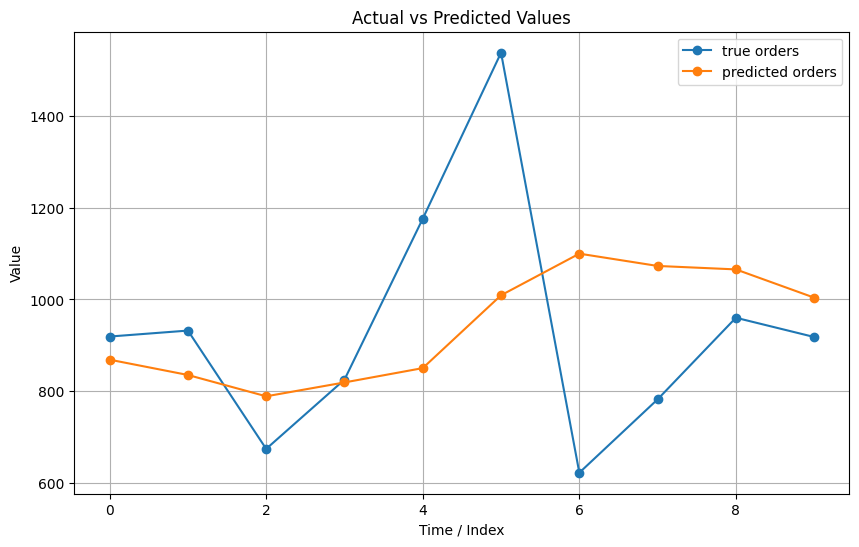

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(y_true[0], marker="o", label="true orders")
plt.plot(y_pred[0], marker="o", label="predicted orders")

plt.title('Actual vs Predicted Values')
plt.xlabel('Time / Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

## 7. Evaluate — MAE, RMSE, SMAPE, RMSLE

All four are computed in **raw order space** (after `expm1`), **per horizon**. The MAE,
SMAPE, and RMSLE definitions match `src/evaluate.py` exactly, so they line up with the
tree baselines in `results/all_models_rmsle.csv`; RMSE is the extra one you asked for.

- **MAE**   = mean(|y − ŷ|)
- **RMSE**  = sqrt(mean((y − ŷ)²))
- **SMAPE** = mean(|y − ŷ| / ((|y| + |ŷ|) / 2)) × 100
- **RMSLE** = sqrt(mean((log1p(clip(ŷ, 0)) − log1p(y))²))   — equals `val_rmsle()` when both are in log1p space

In [92]:
def compute_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred), axis=0)

def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))

def compute_smape(y_true, y_pred):
    num = np.abs(y_true - y_pred)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    ratio = np.where(den == 0, 0.0, num / np.where(den == 0, 1.0, den))
    return np.mean(ratio, axis=0) * 100.0

def compute_rmsle(y_true, y_pred):
    out = np.empty(y_true.shape[1])
    for h in range(y_true.shape[1]):
        d = np.log1p(np.clip(y_pred[:, h], 0, None)) - np.log1p(y_true[:, h])
        out[h] = np.sqrt(np.mean(d ** 2))
    return out

# Score the FULL eval set: y_true / y_pred are (N_eval, HORIZON), so axis-0 averages
# over samples and leaves one value per horizon. The earlier y_true[0]/y_pred[0]
# version scored a single window, which is why every horizon printed the same number.
metrics = pd.DataFrame(
    {
        "MAE":   compute_mae(y_true, y_pred),
        "RMSE":  compute_rmse(y_true, y_pred),
        "SMAPE": compute_smape(y_true, y_pred),
        "RMSLE": compute_rmsle(y_true, y_pred),
    },
    index=[f"h{h + 1}" for h in range(HORIZON)],
)
metrics.loc["mean"] = metrics.mean()
print("eval samples:", len(y_true))
metrics.round(4)

eval samples: 20985


,MAE,RMSE,SMAPE,RMSLE
h1,149.9652,398.4574,41.8418,0.6047
h2,149.0982,396.1833,41.8507,0.6026
h3,142.8508,374.0670,41.7448,0.6000
h4,138.0242,365.2719,41.2423,0.5947
h5,131.9242,348.4990,40.6222,0.5775
h6,127.8788,337.3296,40.0171,0.5693
h7,122.0665,275.6805,40.0803,0.5690
h8,117.8807,238.9488,39.7205,0.5592
h9,113.0658,186.9048,39.7638,0.5542
h10,111.4162,184.0550,40.0562,0.5614


### Where to go from here

- **`df`** is your single all-features table; `X_train / Y_train / ...` are the model-ready tensors.
- Tune the architecture in `LSTMForecaster` (hidden size, layers, dropout, bidirectional).
- Add early stopping + an LR scheduler on `val_rmsle()` (see `src/lstm_model.py` for a worked version).
- Trim `FEATURE_COLS` — the static per-series columns (encodings, `*_mean_orders`, price aggregates)
  repeat at every timestep; you may prefer to fuse them only at the head, as `DemandRNN` does.
- Compare against the tree baselines in `results/all_models_rmsle.csv`.

## 8. Compare the LSTM with the ML / baseline models

One table, **mean over horizons h1..h10 on the eval split**, recomputing MAE / RMSE / SMAPE / RMSLE
for every model in `results/predictions/` with the same metric functions as section 7 — so the LSTM
sits in the same table as `xgboost`, `lightgbm`, `catboost`, `random_forest`, `linreg`, and the
naive/seasonal/SMA/SES baselines.

- **`lstm (notebook)`** — this notebook's freshly trained model (full eval arrays).
- **`lstm (saved)`** — the tuned `src/lstm_model.py` run saved under `results/predictions/`.

> **Fairness caveat:** the tree/baseline predictions are a single-origin (week-125) 10-step forecast,
> while the notebook LSTM is scored over rolling anchors 126–135. Same target weeks, different sample
> populations — so treat cross-model gaps as indicative, not exact. (Trees usually keep the MAE edge;
> the LSTM tends to win on RMSLE.)

In [93]:
## 8. Compare the LSTM with the ML / baseline models
#
# Every model's eval predictions live in results/predictions/pred_<model>_h<HH>.csv as
# (center_id, meal_id, week, y_pred, split). We recompute MAE / RMSE / SMAPE / RMSLE from
# those files with the SAME functions used in section 7, so the numbers are apples-to-apples
# with the LSTM. Ground truth = expm1(y_log) (raw order counts), keyed by the 3 id columns.
#
# Recomputing from predictions (rather than reading results/all_models_*.csv) buys us two
# things: RMSE, which the saved CSVs don't carry, and one consistent positive-% SMAPE
# (all_models_smape.csv uses a different, negative convention).
#
# FAIRNESS CAVEAT: the saved tree/baseline predictions are a single-origin (week-125)
# 10-step forecast (~3.5k series), while this notebook's LSTM is scored over rolling
# anchors 126..135 (~21k windows). The target weeks overlap but the sample populations
# differ, so read cross-model gaps as indicative, not exact.
import re

PRED_DIR = ROOT / "results" / "predictions"

# raw-order ground truth (y_log was captured BEFORE the features were scaled/dropped)
truth = df[["center_id", "meal_id", "week"]].copy()
truth["y_true"] = np.expm1(df["y_log"].to_numpy())

def metrics_from_pred_files(model):
    """Per-horizon (MAE, RMSE, SMAPE, RMSLE), each shape (HORIZON,), from a model's eval files."""
    mae = np.full(HORIZON, np.nan); rmse = np.full(HORIZON, np.nan)
    smape = np.full(HORIZON, np.nan); rmsle = np.full(HORIZON, np.nan)
    for h in range(HORIZON):
        f = PRED_DIR / f"pred_{model}_h{h + 1:02d}.csv"
        if not f.exists():
            return None
        p = pd.read_csv(f)
        p = p[p["split"] == "eval"].merge(truth, on=["center_id", "meal_id", "week"], how="inner")
        yt = p["y_true"].to_numpy()[:, None]
        yp = p["y_pred"].to_numpy()[:, None]
        mae[h]   = compute_mae(yt, yp)[0]
        rmse[h]  = compute_rmse(yt, yp)[0]
        smape[h] = compute_smape(yt, yp)[0]
        rmsle[h] = compute_rmsle(yt, yp)[0]
    return mae, rmse, smape, rmsle

# discover every saved model from the prediction filenames
models = sorted(re.match(r"pred_(.+)_h01", f.stem).group(1)
                for f in PRED_DIR.glob("pred_*_h01.csv"))

rows = {}
for m in models:
    r = metrics_from_pred_files(m)
    if r is None:
        continue
    label = "lstm (saved)" if m == "lstm" else m
    rows[label] = [v.mean() for v in r]      # mean over horizons h1..h10

# this notebook's freshly trained LSTM (full eval arrays, not just sample 0)
rows["lstm (notebook)"] = [
    compute_mae(y_true, y_pred).mean(),
    compute_rmse(y_true, y_pred).mean(),
    compute_smape(y_true, y_pred).mean(),
    compute_rmsle(y_true, y_pred).mean(),
]

comparison = (pd.DataFrame(rows, index=["MAE", "RMSE", "SMAPE", "RMSLE"]).T
              .sort_values("MAE"))
print("eval split — mean over horizons h1..h10 (lower is better)")
comparison.round(3)

eval split — mean over horizons h1..h10 (lower is better)


,MAE,RMSE,SMAPE,RMSLE
xgboost,110.624,298.391,45.592,0.625
lightgbm,110.887,298.174,45.554,0.626
random_forest,112.257,295.963,46.048,0.634
catboost,112.437,298.678,45.994,0.629
linreg,122.159,296.392,52.733,0.757
ses,126.195,306.033,49.401,0.696
lstm (notebook),130.417,310.540,40.694,0.579
lstm (saved),135.382,374.066,37.603,0.540
naive,138.641,341.581,55.741,0.826
sma,139.977,343.027,53.068,0.786
